<a href="https://colab.research.google.com/github/Claudio0311/Machine_Learning_para_Significancia_de_terremotos/blob/main/Proyecto_Inteligencia_Artificial%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Análisis y predicción del nivel de significancia de terremotos mediante Machine Learning**

##Integrantes
* Alex Santiago Salamanca Toloza-2231873
* Camilo Andrés Velandia Mendoza-2232728
* Jhoan Sebastian Pinzón Mogotocoro - 2191958


## Dataset

Este dataset documenta 1000 eventos sísmicos registrados entre 1995 a 2023, consolidando en un solo lugar la magnitud, ubicación geográfica exacta y el impacto real de cada temblor a través de sistemas de alerta y riesgo de tsunami. Al combinar variables técnicas de precisión (como la red de estaciones y el desfase azimutal) con indicadores de intensidad percibida (CDI y MMI), el conjunto de datos permite analizar no solo dónde y qué tan fuerte se movió la Tierra, sino qué tan confiable es la medición y qué tan grave fue la huella que dejó en el país o continente afectado.

Dicho dataset se puede ver en el siguiente [enlace.](https://www.kaggle.com/datasets/warcoder/earthquake-dataset)

---

## Columnas

* title: Nombre oficial del terremoto.
* magnitude: El tamaño o potencia del sismo.
* date_time: Cuándo ocurrió el evento.
* cdi: Intensidad máxima reportada por personas (qué tanto se sintió).
* mmi: Intensidad máxima medida por instrumentos.
* alert: Color de la emergencia (verde, amarillo, naranja, rojo).
* tsunami: Si ocurrió en el océano y hubo riesgo de olas (1 = sí, 0 = no).
* sig: Un puntaje (0 a 1000) que indica qué tan "importante" fue el evento según su daño y potencia.
* net: Identificador de la red sísmica que envió la información.
* nst: Número de estaciones que detectaron el sismo (más estaciones = mejor dato).
* dmin: Distancia a la estación más cercana (ayuda a saber la precisión).
* gap: El "hueco" entre estaciones; mientras más pequeño sea este número, más confiable es la ubicación del sismo.
* magType: El método científico usado para calcular la magnitud.
* depth: Profundidad (en km) donde se originó la ruptura.
* latitude / longitude: Coordenadas GPS exactas.
* location: Descripción de la zona afectada.
* continent / country: Continente y país del impacto.



In [ ]:
#@title Importaciones
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score

In [ ]:
# @title codigo
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#@title Carga Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
df = pd.read_csv('/content/drive/MyDrive/earthquake_1995-2023.csv') # Please update the path to your dataset if it's different
df.head()

,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,16-08-2023 12:47,7,4,green,0,657,us,114,7.177000,25.0,mww,192.955,-13.8814,167.1580,"Sola, Vanuatu",NaN,Vanuatu
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,19-07-2023 00:22,8,6,yellow,0,775,us,92,0.679000,40.0,mww,69.727,12.8140,-88.1265,"Intipucá, El Salvador",NaN,NaN
2,"M 6.6 - 25 km ESE of Loncopué, Argentina",6.6,17-07-2023 03:05,7,5,green,0,899,us,70,1.634000,28.0,mww,171.371,-38.1911,-70.3731,"Loncopué, Argentina",South America,Argentina
3,"M 7.2 - 98 km S of Sand Point, Alaska",7.2,16-07-2023 06:48,6,6,green,1,860,us,173,0.907000,36.0,mww,32.571,54.3844,-160.6990,"Sand Point, Alaska",NaN,NaN
4,M 7.3 - Alaska Peninsula,7.3,16-07-2023 06:48,0,5,NaN,1,820,at,79,0.879451,172.8,Mi,21.000,54.4900,-160.7960,Alaska Peninsula,NaN,NaN


In [ ]:
#@title Resumen estadístico
df.describe()

,magnitude,cdi,mmi,tsunami,sig,nst,dmin,gap,depth,latitude,longitude
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,6.940150,3.605000,6.02700,0.325000,847.915000,193.918000,1.125174,20.926290,74.612541,4.315554,51.486576
std,0.438148,3.328972,1.43399,0.468609,301.802632,239.045858,2.073164,24.415895,130.812590,26.633320,117.478302
min,6.500000,0.000000,1.00000,0.000000,650.000000,0.000000,0.000000,0.000000,2.700000,-61.848400,-179.968000
25%,6.600000,0.000000,5.00000,0.000000,691.000000,0.000000,0.000000,0.000000,16.000000,-13.518500,-71.694450
50%,6.800000,4.000000,6.00000,0.000000,744.000000,0.000000,0.000000,18.000000,29.000000,-2.443500,107.791000
75%,7.100000,7.000000,7.00000,1.000000,874.250000,403.000000,1.549250,27.000000,55.000000,25.167250,148.364750
max,9.100000,9.000000,10.00000,1.000000,2910.000000,934.000000,17.654000,239.000000,670.810000,71.631200,179.662000


In [ ]:
#@title Columnas
df.columns

Index(['title', 'magnitude', 'date_time', 'cdi', 'mmi', 'alert', 'tsunami',
       'sig', 'net', 'nst', 'dmin', 'gap', 'magType', 'depth', 'latitude',
       'longitude', 'location', 'continent', 'country'],
      dtype='object')

In [ ]:
#@title Información Básica
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   title      1000 non-null   object 
 1   magnitude  1000 non-null   float64
 2   date_time  1000 non-null   object 
 3   cdi        1000 non-null   int64  
 4   mmi        1000 non-null   int64  
 5   alert      449 non-null    object 
 6   tsunami    1000 non-null   int64  
 7   sig        1000 non-null   int64  
 8   net        1000 non-null   object 
 9   nst        1000 non-null   int64  
 10  dmin       1000 non-null   float64
 11  gap        1000 non-null   float64
 12  magType    1000 non-null   object 
 13  depth      1000 non-null   float64
 14  latitude   1000 non-null   float64
 15  longitude  1000 non-null   float64
 16  location   994 non-null    object 
 17  continent  284 non-null    object 
 18  country    651 non-null    object 
dtypes: float64(6), int64(5), object(8)
memory usage: 

Q1: 6.6
Q3: 7.1
IQR: 0.5


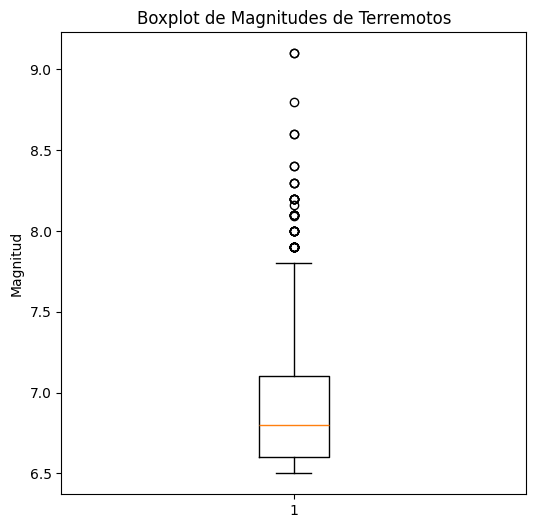

Q1: 16.0
Q3: 55.0
IQR: 39.0


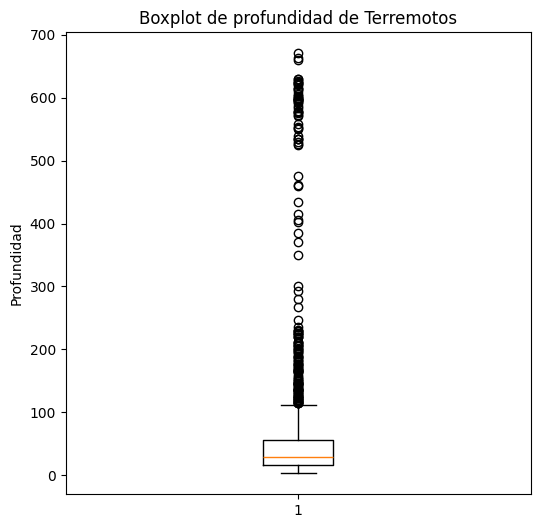

In [ ]:
#@title Boxplot de magnitudes
magnitudes = df["magnitude"].dropna()

# cuartiles
Q1 = magnitudes.quantile(0.25)
Q3 = magnitudes.quantile(0.75)
IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

# crear el boxplot
plt.figure(figsize=(6,6))
plt.boxplot(magnitudes)

plt.title("Boxplot de Magnitudes de Terremotos")
plt.ylabel("Magnitud")
plt.show()

################################################################################
#@title Boxplot de profundidad de terremotos
profundidad = df["depth"].dropna()

# cuartiles
Q1 = profundidad.quantile(0.25)
Q3 = profundidad.quantile(0.75)
IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

# crear el boxplot
plt.figure(figsize=(6,6))
plt.boxplot(profundidad)

plt.title("Boxplot de profundidad de Terremotos")
plt.ylabel("Profundidad")
plt.show()

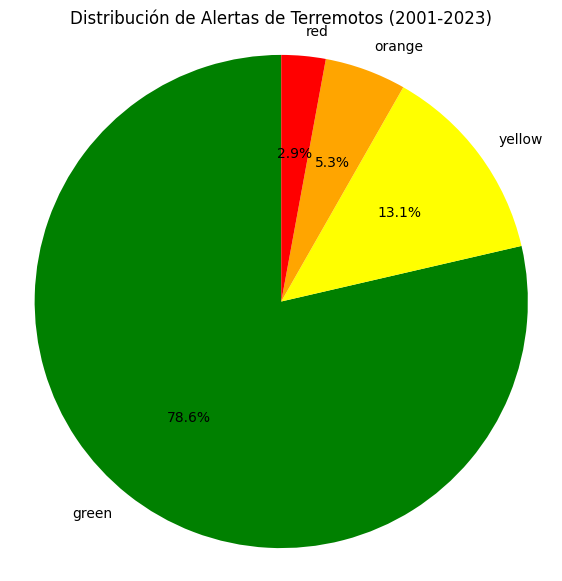

In [ ]:
#@title Diagrama de pie para alertas
alert_counts = df["alert"].value_counts()

labels = alert_counts.index
sizes = alert_counts.values

colors = ["green", "yellow", "orange", "red"]

plt.figure(figsize=(7,7))
plt.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    colors=colors,
    startangle=90
)

plt.title("Distribución de Alertas de Terremotos (2001-2023)")
plt.axis("equal")

plt.show()

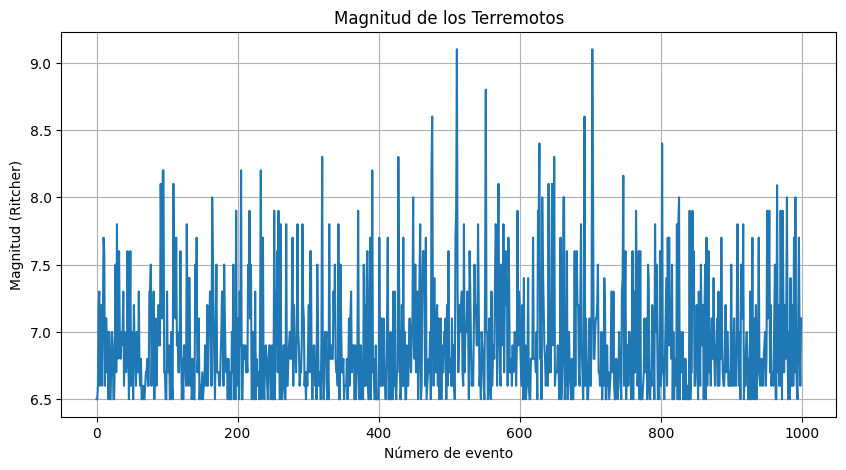

In [ ]:
#@title Magnitud de terremotos
plt.figure(figsize=(10,5))
plt.plot(df["magnitude"])

plt.title("Magnitud de los Terremotos")
plt.xlabel("Número de evento")
plt.ylabel("Magnitud (Ritcher)")
plt.grid(True)

plt.show()

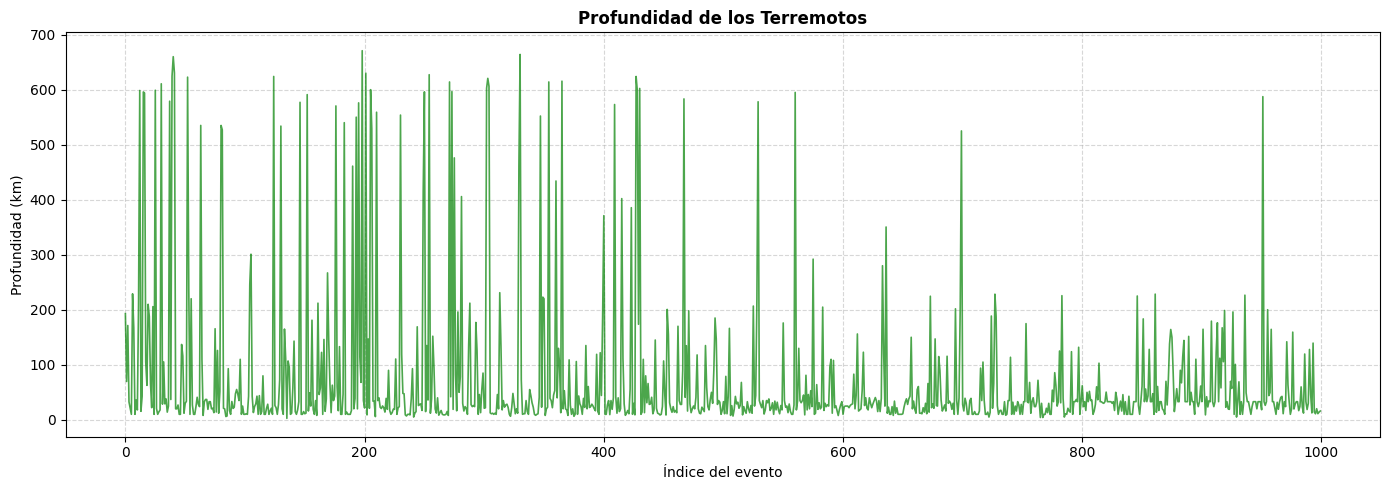

In [ ]:
# @title Profundidad
n_primeros = 1000
indices = range(n_primeros)
magnitud = df['magnitude'].values[:n_primeros]
profundidad = df['depth'].values[:n_primeros]
plt.figure(figsize=(14,5))
plt.plot(indices, profundidad, color='green', alpha=0.7, linewidth=1.2)
plt.title('Profundidad de los Terremotos', fontweight='bold')
plt.xlabel('Índice del evento')
plt.ylabel('Profundidad (km)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Matriz de correlación


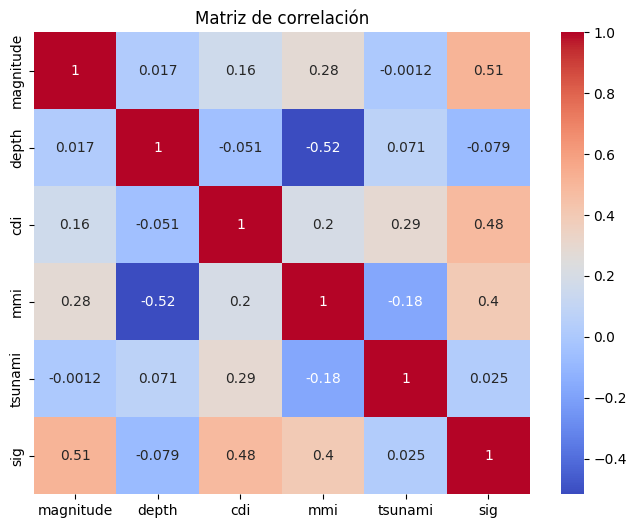

In [ ]:
# @title
import seaborn as sns
data = df[["magnitude", "depth", "cdi", "mmi", "tsunami", "sig"]]
data = data.dropna()

# 2. Matriz de correlación

plt.figure(figsize=(8,6))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

# **ENTREGA 2**

## **Limpieza y Preparación del Dataset**

Este es el código para identificar y manejar valores nulos. En esta etapa se seleccionan las variables relevantes para el modelo y se verifica la presencia de valores nulos. En caso de existir registros incompletos, estos serán eliminados para evitar errores durante el entrenamiento. Se optó por eliminar registros incompletos únicamente en las columnas utilizadas por el modelo, ya que los modelos supervisados implementados no admiten valores nulos directamente.

In [ ]:
#@title Preprocesamiento y limpieza de datos
import pandas as pd

print('Valores nulos antes de la limpieza (columnas relevantes):')
print(df[["magnitude", "depth", "cdi", "mmi", "tsunami", "sig"]].isnull().sum())

# Selecciona las columnas relevantes para el modelo
data_cleaned = df[["magnitude", "depth", "cdi", "mmi", "tsunami", "sig"]].copy()

# Elimina filas con valores nulos en estas columnas
# Si hay filas con NaN,las eliminará.
data_cleaned.dropna(inplace=True)

# Elimina filas duplicadas
data_cleaned.drop_duplicates(inplace=True)

print('\nValores nulos después de la limpieza (columnas relevantes):')
print(data_cleaned[["magnitude", "depth", "cdi", "mmi", "tsunami", "sig"]].isnull().sum())

print("\nFilas duplicadas después de limpiar:", data_cleaned.duplicated().sum())

print('\nDimensiones del dataset después de la limpieza:', data_cleaned.shape)

print("\nResumen de la variable objetivo `sig`:")
print(data_cleaned["sig"].describe())

Valores nulos antes de la limpieza (columnas relevantes):
magnitude    0
depth        0
cdi          0
mmi          0
tsunami      0
sig          0
dtype: int64

Valores nulos después de la limpieza (columnas relevantes):
magnitude    0
depth        0
cdi          0
mmi          0
tsunami      0
sig          0
dtype: int64

Filas duplicadas después de limpiar: 0

Dimensiones del dataset después de la limpieza: (938, 6)

Resumen de la variable objetivo `sig`:
count     938.000000
mean      857.646055
std       308.699974
min       650.000000
25%       691.000000
50%       754.000000
75%       889.000000
max      2910.000000
Name: sig, dtype: float64


### Particionado de datos 80/20 con Shuffle

## División del dataset en entrenamiento y prueba

Para evaluar el desempeño de los modelos, el dataset se divide en dos subconjuntos: entrenamiento y prueba. El conjunto de entrenamiento corresponde al 80% de los datos y se utiliza para ajustar los modelos. El conjunto de prueba corresponde al 20% restante y permite evaluar la capacidad de generalización sobre datos no vistos.

La función `train_test_split` realiza una mezcla aleatoria de los datos por defecto mediante el parámetro `shuffle=True`. Además, se define `random_state=42` para garantizar que la partición sea reproducible.

In [ ]:
# @title División del dataset en entrenamiento y prueba
from sklearn.model_selection import train_test_split

# Asumiendo que X y y ya están definidos como en la celda anterior:
X = data_cleaned[["magnitude", "depth", "cdi", "mmi", "tsunami"]]
y = data_cleaned["sig"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2, # 20% para el conjunto de prueba
    random_state=42, # Para asegurar la reproducibilidad de la división
    shuffle=True
)

print(f"Tamaño del conjunto de entrenamiento (X_train): {X_train.shape}")
print(f"Tamaño del conjunto de prueba (X_test): {X_test.shape}")
print(f"Tamaño del conjunto de entrenamiento y_train: {y_train.shape}")
print(f"Tamaño del conjunto de prueba y_test: {y_test.shape}")

Tamaño del conjunto de entrenamiento (X_train): (750, 5)
Tamaño del conjunto de prueba (X_test): (188, 5)
Tamaño del conjunto de entrenamiento y_train: (750,)
Tamaño del conjunto de prueba y_test: (188,)


# **MODELO 1: ÁRBOL DE DECISIÓN (Decision Tree) con Tuning de `max_depth`**

El modelo de Árbol de Decisión es un modelo no paramétrico que divide el espacio de características en regiones rectangulares para hacer predicciones. El hiperparámetro `max_depth` controla la profundidad máxima del árbol, lo cual es crucial para evitar el sobreajuste.

Aquí evaluaremos el rendimiento del modelo ajustando `max_depth`.

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

# Valores de max_depth a evaluar
max_depth_values = [1, 2, 3, 4, 5, 6, 8, 10, None]

resultados_dt = []

# Tuning manual de max_depth
for depth in max_depth_values:
    regressor_dt_temp = DecisionTreeRegressor(
        max_depth=depth,
        random_state=42
    )

    regressor_dt_temp.fit(X_train, y_train)
    y_pred_temp = regressor_dt_temp.predict(X_test)

    mse = mean_squared_error(y_test, y_pred_temp)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred_temp)

    resultados_dt.append({
        "max_depth": depth if depth is not None else "None",
        "RMSE": rmse,
        "MAE": mae,
        "MSE": mse

    })

# Convertir a DataFrame
resultados_dt_df = pd.DataFrame(resultados_dt)

# Ordenar por RMSE (menor es mejor)
resultados_dt_df = resultados_dt_df.sort_values(by="RMSE")

print("=== Resultados del tuning de Decision Tree ===")
display(resultados_dt_df)

# Seleccionar mejor max_depth
mejor_depth = resultados_dt_df.iloc[0]["max_depth"]
mejor_depth_modelo = None if mejor_depth == "None" else int(mejor_depth)

# Modelo final
regressor_dt = DecisionTreeRegressor(
    max_depth=mejor_depth_modelo,
    random_state=42
)

regressor_dt.fit(X_train, y_train)

# Predicción final
y_pred_dt = regressor_dt.predict(X_test)

# Métricas finales
print("\n=== Mejor modelo Decision Tree ===")
print("Mejor max_depth:", mejor_depth)
print("RMSE %.3f" % np.sqrt(mean_squared_error(y_test, y_pred_dt)))
print("MAE %.3f" % mean_absolute_error(y_test, y_pred_dt))
print("MSE %.3f" % mean_squared_error(y_test, y_pred_dt))

=== Resultados del tuning de Decision Tree ===


,max_depth,RMSE,MAE,MSE
2,3,246.365900,130.957758,60696.156478
3,4,250.076352,121.293627,62538.181740
4,5,252.472399,117.024027,63742.312286
1,2,254.933191,134.653559,64990.931710
6,8,260.883697,111.894255,68060.303112
5,6,261.110173,116.092822,68178.522379
0,1,269.842390,166.063268,72814.915230
7,10,281.278562,128.797452,79117.629466
8,None,289.982217,131.037234,84089.686170



=== Mejor modelo Decision Tree ===
Mejor max_depth: 3
RMSE 246.366
MAE 130.958
MSE 60696.156


Para el modelo de Árbol de Decisión se realizó un proceso de tuning manual del hiperparámetro `max_depth`, evaluando diferentes profundidades: 1, 2, 3, 4, 5, 6, 8, 10 y sin límite de profundidad (`None`).

Para cada valor se entrenó un modelo independiente y se calcularon las métricas MSE, RMSE y MAE sobre el conjunto de prueba. Luego, los resultados se organizaron en una tabla y se ordenaron según el RMSE, ya que esta métrica penaliza con mayor fuerza los errores grandes.

A partir de este proceso, se seleccionó automáticamente el valor de `max_depth` que obtuvo el menor RMSE. Con este mejor valor se entrenó nuevamente el modelo final de Árbol de Decisión y se generaron las predicciones finales sobre el conjunto de prueba.

# **MODELO 2: RANDOM FOREST con Tuning de `n_estimators`**

Para el modelo Random Forest se realizó un ajuste al hiperparámetro `n_estimators`, evaluando diferentes cantidades de árboles dentro del bosque.

Para cada configuración, se calcularon las métricas MSE, RMSE y MAE sobre el conjunto de prueba. Se seleccionó como mejor modelo aquel que obtuvo el menor valor de RMSE, ya que esta métrica penaliza con mayor fuerza los errores grandes.

El valor final de `n_estimators` fue elegido porque proporciona el mejor desempeño sin incrementar innecesariamente el costo computacional.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# Valores de n_estimators a evaluar
n_estimators_values = [5, 10, 25, 50, 75, 100, 150, 200, 300]

resultados_rf = []

# Tuning manual de n_estimators
for n in n_estimators_values:
    regressor_rf_temp = RandomForestRegressor(
        n_estimators=n,
        random_state=42
    )

    regressor_rf_temp.fit(X_train, y_train)
    y_pred_temp = regressor_rf_temp.predict(X_test)

    mse = mean_squared_error(y_test, y_pred_temp)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred_temp)

    resultados_rf.append({
        "n_estimators": n,
        "RMSE": rmse,
        "MAE": mae,
        "MSE": mse
    })

# Convertir resultados a DataFrame
resultados_rf_df = pd.DataFrame(resultados_rf)

# Ordena por RMSE de menor a mayor
resultados_rf_df = resultados_rf_df.sort_values(by="RMSE")

print("=== Resultados del tuning de Random Forest ===")
display(resultados_rf_df)

# Seleccionar el mejor n_estimators
mejor_n_estimators = int(resultados_rf_df.iloc[0]["n_estimators"])

# Entrenar el modelo final con el mejor valor encontrado
regressor_rf = RandomForestRegressor(
    n_estimators=mejor_n_estimators,
    random_state=42
)

regressor_rf.fit(X_train, y_train)

# Predicción final
y_pred_rf = regressor_rf.predict(X_test)

# Métricas finales
print("\n=== Mejor modelo Random Forest ===")
print("Mejor n_estimators:", mejor_n_estimators)
print("MSE %.3f" % mean_squared_error(y_test, y_pred_rf))
print("RMSE %.3f" % np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("MAE %.3f" % mean_absolute_error(y_test, y_pred_rf))

=== Resultados del tuning de Random Forest ===


,n_estimators,RMSE,MAE,MSE
2,25,232.207778,104.692908,53920.451956
6,150,234.056616,105.584141,54782.499379
5,100,234.977118,105.849570,55214.245847
7,200,235.132144,105.210947,55287.125299
8,300,235.146208,104.851246,55293.738942
3,50,236.360956,106.833514,55866.501638
4,75,237.162213,107.125112,56245.915272
1,10,239.631645,109.940957,57423.325053
0,5,275.096617,127.833511,75678.148564



=== Mejor modelo Random Forest ===
Mejor n_estimators: 25
MSE 53920.452
RMSE 232.208
MAE 104.693


# **MODELO 3: MÁQUINAS DE VECTORES DE SOPORTE (SVM) con Diferentes Kernels**

Las Máquinas de Vectores de Soporte pueden aplicarse a problemas de regresión mediante el modelo `SVR`. En este caso, el objetivo no es clasificar, sino predecir el valor numérico de la variable `sig`, que representa el puntaje de significancia del terremoto. Debido a que este algoritmo es sensible a la escala de las variables, se aplica `StandardScaler` a las variables predictoras (`X_train` y `X_test`) antes del entrenamiento. La variable `sig` se conserva en su escala original para que las métricas MSE, RMSE y MAE puedan interpretarse en unidades reales y compararse de forma coherente con los demás modelos.

Para evaluar el desempeño del modelo SVM, se compararon tres kernels: lineal, polinomial y RBF. A partir del proceso de tuning manual, el kernel RBF obtuvo el mejor rendimiento, por lo que fue seleccionado como la configuración final del modelo SVM.

In [ ]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

# =========================
# ESCALADO DE DATOS
# =========================

# Escala variables predictoras
scaler_X = StandardScaler()
X_train_s = scaler_X.fit_transform(X_train)
X_test_s = scaler_X.transform(X_test)

# Escala variable objetivo
scaler_y = StandardScaler()
y_train_s = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()

# =========================
# TUNING DE SVM (KERNELS)
# =========================

kernels = [
    {"nombre": "Linear", "kernel": "linear"},
    {"nombre": "Polynomial", "kernel": "poly", "degree": 3},
    {"nombre": "RBF", "kernel": "rbf"}
]

resultados_svm = []

for config in kernels:

    # Crea el modelo según kernel
    if config["kernel"] == "poly":
        regressor_svm = SVR(
            kernel=config["kernel"],
            degree=config["degree"],
            C=1.0,
            epsilon=0.1
        )
    else:
        regressor_svm = SVR(
            kernel=config["kernel"],
            C=1.0,
            epsilon=0.1
        )

    # Entrenar
    regressor_svm.fit(X_train_s, y_train_s)

    # Predicción (escala normalizada)
    y_pred_s = regressor_svm.predict(X_test_s)

    # Regresar a escala original
    y_pred = scaler_y.inverse_transform(y_pred_s.reshape(-1, 1)).ravel()

    # Métricas
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)

    resultados_svm.append({
        "Kernel": config["nombre"],
        "RMSE": rmse,
        "MAE": mae,
        "MSE": mse
    })

# Tabla de resultados
resultados_svm_df = pd.DataFrame(resultados_svm)
resultados_svm_df = resultados_svm_df.sort_values(by="RMSE")

print("=== Resultados SVM ===")
display(resultados_svm_df)

# =========================
# SELECCIÓN DEL MEJOR KERNEL
# =========================

mejor_kernel = resultados_svm_df.iloc[0]["Kernel"]

# Crea el modelo final
if mejor_kernel == "Linear":
    regressor_svm = SVR(kernel="linear", C=1.0, epsilon=0.1)
elif mejor_kernel == "Polynomial":
    regressor_svm = SVR(kernel="poly", degree=3, C=1.0, epsilon=0.1)
else:
    regressor_svm = SVR(kernel="rbf", C=1.0, epsilon=0.1)

# Entrena modelo final
regressor_svm.fit(X_train_s, y_train_s)

# Predicción final
y_pred_svm_s = regressor_svm.predict(X_test_s)
y_pred_svm = scaler_y.inverse_transform(y_pred_svm_s.reshape(-1, 1)).ravel()

# Métricas finales
print("\n=== Mejor modelo SVM ===")
print("Mejor kernel:", mejor_kernel)
print("RMSE %.3f" % np.sqrt(mean_squared_error(y_test, y_pred_svm)))
print("MAE %.3f" % mean_absolute_error(y_test, y_pred_svm))
print("MSE %.3f" % mean_squared_error(y_test, y_pred_svm))

=== Resultados SVM ===


,Kernel,RMSE,MAE,MSE
2,RBF,247.103993,104.491410,61060.383159
1,Polynomial,264.253377,125.021302,69829.847361
0,Linear,286.595559,123.405550,82137.014221



=== Mejor modelo SVM ===
Mejor kernel: RBF
RMSE 247.104
MAE 104.491
MSE 61060.383


# **Cross Validation: Decision Tree**

Para la `cross-validation` se utilizó K-Fold con `k = 10`, `shuffle=True` y `random_state=42`.

Este valor se seleccionó porque representa un equilibrio adecuado entre estabilidad en la estimación del error y costo computacional. Valores bajos de k pueden generar estimaciones con alta variabilidad, mientras que valores muy altos incrementan el costo computacional sin aportar mejoras significativas en datasets de tamaño moderado.

Dado que el dataset contiene aproximadamente 1000 registros, k = 10 es una elección estándar ampliamente utilizada en la práctica.

In [ ]:
from sklearn.model_selection import cross_val_score, KFold
import numpy as np

k = 10

kfold = KFold(n_splits=k, shuffle=True, random_state=42)

scores = cross_val_score(
    regressor_dt, X, y,
    cv=kfold,
    scoring='neg_mean_squared_error'
)

rmse_scores = np.sqrt(-scores)

print(f"=== Decision Tree | k = {k} ===")
print("RMSE por fold:", rmse_scores)
print("\nRMSE promedio: %.3f" % rmse_scores.mean())
print("Desviación estándar: %.3f" % rmse_scores.std())

=== Decision Tree | k = 10 ===
RMSE por fold: [245.17508749 251.56463549 305.25395102 216.87955389 205.85031993
 290.32562443 194.09894711 197.56206826 179.59786061 160.5633821 ]

RMSE promedio: 224.687
Desviación estándar: 44.915


# **Cross Validation – Random Forest**

In [ ]:
from sklearn.model_selection import cross_val_score, KFold
import numpy as np

k = 10

kfold = KFold(n_splits=k, shuffle=True, random_state=42)

scores = cross_val_score(
    regressor_rf, X, y,
    cv=kfold,
    scoring='neg_mean_squared_error'
)

rmse_scores = np.sqrt(-scores)

print(f"=== Random Forest | k = {k} ===")
print("RMSE por fold:", rmse_scores)
print("\nRMSE promedio: %.3f" % rmse_scores.mean())
print("Desviación estándar: %.3f" % rmse_scores.std())

=== Random Forest | k = 10 ===
RMSE por fold: [237.60530833 236.26009326 300.85924377 199.7711533  210.32052843
 261.43034593 230.5350576  178.47340848 205.79350059 194.69725219]

RMSE promedio: 225.575
Desviación estándar: 34.203


# **Cross Validation – SVM (RBF)**

In [ ]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
import numpy as np

k = 10

kfold = KFold(n_splits=k, shuffle=True, random_state=42)

scoring = {
    'rmse': 'neg_root_mean_squared_error',
    'mae': 'neg_mean_absolute_error'
}

pipeline_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="rbf", C=1.0, epsilon=0.1))
])

cv_svm = cross_validate(
    pipeline_svm,
    X,
    y,
    cv=kfold,
    scoring=scoring
)

print(f"=== SVM (RBF) | k = {k} ===")
print("RMSE por fold:", -cv_svm['test_rmse'])
print("\nRMSE promedio: %.3f" % (-cv_svm['test_rmse'].mean()))
print("MAE promedio: %.3f" % (-cv_svm['test_mae'].mean()))

=== SVM (RBF) | k = 10 ===
RMSE por fold: [323.59362943 338.49265289 431.1401991  276.35593497 229.61512502
 386.65614354 247.40193356 234.44566512 238.64436978 227.16497157]

RMSE promedio: 293.351
MAE promedio: 133.421


# **MODELO 4: Deep Learning percepcion multiple**

In [ ]:
import tensorflow as tf
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Escalado
scaler_X_dl = StandardScaler()
scaler_y_dl = StandardScaler()

X_train_dl = scaler_X_dl.fit_transform(X_train)
X_test_dl = scaler_X_dl.transform(X_test)

y_train_dl = scaler_y_dl.fit_transform(
    y_train.values.reshape(-1, 1)
).ravel()

# y_test en escala original
y_test_real = y_test.values.ravel()

## **Modelo 4.1: MLP con capas ocultas (64, 128, 128)**

El modelo MLP_1 corresponde a una red neuronal tipo Perceptrón Multicapa con tres capas ocultas (64, 128 y 128 neuronas) y función de activación ReLU, adecuada para capturar relaciones no lineales. Previamente se aplicó escalado a los datos, ya que las redes neuronales son sensibles a la magnitud de las variables. Las métricas se presentan tanto en escala normalizada (propia del entrenamiento) como en escala real, siendo esta última la utilizada para comparar el desempeño con los demás modelos.

In [ ]:
#@title **code** MLP_1: arquitectura (64, 128, 128)

import tensorflow as tf
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

EPOCHS_MLP1 = 10

# Fijar semilla para mayor reproducibilidad
tf.keras.utils.set_random_seed(42)

# Crear modelo
model_mlp1 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_dl.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(1)
])

model_mlp1.summary()

# Compilar modelo
model_mlp1.compile(
    optimizer='adam',
    loss='mse'
)

# Entrenar modelo
history_mlp1 = model_mlp1.fit(
    X_train_dl,
    y_train_dl,
    epochs=EPOCHS_MLP1,
    batch_size=32,
    verbose=1
)

# =========================
# PREDICCIONES
# =========================

# Predicción en escala normalizada
y_pred_mlp1_s = model_mlp1.predict(X_test_dl, verbose=0).ravel()

# Variable real normalizada para comparar en escala normalizada
y_test_s = scaler_y_dl.transform(
    y_test_real.reshape(-1, 1)
).ravel()

# Predicción transformada nuevamente a escala real
y_pred_mlp1 = scaler_y_dl.inverse_transform(
    y_pred_mlp1_s.reshape(-1, 1)
).ravel()

# =========================
# MÉTRICAS EN ESCALA NORMALIZADA
# =========================

print(f"\nMLP_1 ({EPOCHS_MLP1} epochs) - Escala normalizada")
print("RMSE %.3f" % np.sqrt(mean_squared_error(y_test_s, y_pred_mlp1_s)))
print("MAE  %.3f" % mean_absolute_error(y_test_s, y_pred_mlp1_s))
print("MSE  %.3f" % mean_squared_error(y_test_s, y_pred_mlp1_s))

# =========================
# MÉTRICAS EN ESCALA REAL
# =========================

print(f"\nMLP_1 ({EPOCHS_MLP1} epochs) - Escala real")
print("RMSE %.3f" % np.sqrt(mean_squared_error(y_test_real, y_pred_mlp1)))
print("MAE  %.3f" % mean_absolute_error(y_test_real, y_pred_mlp1))
print("MSE  %.3f" % mean_squared_error(y_test_real, y_pred_mlp1))

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_53 (Dense)                │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,345 (99.00 KB)

 Trainable params: 25,345 (99.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.7331
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5073
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4528
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.4311
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.4183
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.4058
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3988
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.3911
Epoch 9/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.3852
Epoch 10/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.3792

MLP_1 (10 epochs) - Escala normalizada
RMSE 0.719
MAE  0.344
MSE  0.516

MLP_1 (10 epochs) - Escala real
RMSE 216.627
MAE  103.573
MSE  46927.312


## **Modelo 4.2: MLP con capas ocultas (64, 64, 128, 128, 256, 256)**

El modelo MLP_2 utiliza una arquitectura más profunda que MLP_1, con cinco capas ocultas y función de activación ReLU, buscando capturar relaciones no lineales más complejas. Las métricas se muestran en escala normalizada, correspondiente al entrenamiento de la red, y en escala real, que permite comparar el desempeño con los demás modelos sobre la variable original `sig`.


In [ ]:
#@title **code** MLP_2: arquitectura (64, 128, 128, 256, 256)

EPOCHS_MLP2 = 10

tf.keras.utils.set_random_seed(42)

model_mlp2 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_dl.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(1)
])

model_mlp2.summary()

model_mlp2.compile(
    optimizer='adam',
    loss='mse'
)

history_mlp2 = model_mlp2.fit(
    X_train_dl,
    y_train_dl,
    epochs=EPOCHS_MLP2,
    batch_size=32,
    verbose=1
)

# =========================
# PREDICCIONES
# =========================

# Predicción en escala normalizada
y_pred_mlp2_s = model_mlp2.predict(X_test_dl, verbose=0).ravel()

# Variable real normalizada para comparar en escala normalizada
y_test_s = scaler_y_dl.transform(
    y_test_real.reshape(-1, 1)
).ravel()

# Predicción transformada a escala real
y_pred_mlp2 = scaler_y_dl.inverse_transform(
    y_pred_mlp2_s.reshape(-1, 1)
).ravel()

# =========================
# MÉTRICAS EN ESCALA NORMALIZADA
# =========================

print(f"\nMLP_2 ({EPOCHS_MLP2} epochs) - Escala normalizada")
print("RMSE %.3f" % np.sqrt(mean_squared_error(y_test_s, y_pred_mlp2_s)))
print("MAE  %.3f" % mean_absolute_error(y_test_s, y_pred_mlp2_s))
print("MSE  %.3f" % mean_squared_error(y_test_s, y_pred_mlp2_s))

# =========================
# MÉTRICAS EN ESCALA REAL
# =========================

print(f"\nMLP_2 ({EPOCHS_MLP2} epochs) - Escala real")
print("RMSE %.3f" % np.sqrt(mean_squared_error(y_test_real, y_pred_mlp2)))
print("MAE  %.3f" % mean_absolute_error(y_test_real, y_pred_mlp2))
print("MSE  %.3f" % mean_squared_error(y_test_real, y_pred_mlp2))

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_57 (Dense)                │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,289 (485.50 KB)

 Trainable params: 124,289 (485.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.6860
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.4814
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4643
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4607
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4397
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4175
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4037
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3938
Epoch 9/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3881
Epoch 10/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3751

MLP_2 (10 epochs) - Escala normalizada
RMSE 0.735
MAE  0.328
MSE  0.540

MLP_2 (10 epochs) - Escala real
RMSE 221.595
MAE  98.832
MSE  49104.164


Aunque el modelo MLP_2 posee una arquitectura más profunda que MLP_1, no obtuvo una mejora general en todas las métricas. Esto puede deberse a que una mayor cantidad de capas y neuronas no garantiza mejor rendimiento, especialmente en datasets de tamaño limitado y con pocas épocas de entrenamiento. En este caso, MLP_2 redujo el MAE, pero aumentó el RMSE, lo que indica que presentó algunos errores grandes en ciertas predicciones.

## **Modelo 4.3: MLP con 10 capas ocultas (todas 128 neuronas)**

El modelo MLP_3, con una arquitectura más profunda de 10 capas ocultas con 128 neuronas cada una, mostró una ligera mejora en el desempeño respecto a los modelos anteriores, especialmente en términos de MAE y RMSE. Sin embargo, la mejora no es significativa, lo que indica que aumentar la profundidad del modelo no necesariamente produce grandes ganancias en este problema.

In [ ]:
#@title **code** MLP_3: arquitectura (128 x 10 capas)

EPOCHS_MLP3 = 10

tf.keras.utils.set_random_seed(42)

model_mlp3 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_dl.shape[1],))
])

for _ in range(10):
    model_mlp3.add(tf.keras.layers.Dense(128, activation='relu'))

model_mlp3.add(tf.keras.layers.Dense(1))

model_mlp3.summary()

model_mlp3.compile(
    optimizer='adam',
    loss='mse'
)

history_mlp3 = model_mlp3.fit(
    X_train_dl,
    y_train_dl,
    epochs=EPOCHS_MLP3,
    batch_size=32,
    verbose=1
)

# =========================
# PREDICCIONES
# =========================

y_pred_mlp3_s = model_mlp3.predict(X_test_dl, verbose=0).ravel()

y_test_s = scaler_y_dl.transform(
    y_test_real.reshape(-1, 1)
).ravel()

y_pred_mlp3 = scaler_y_dl.inverse_transform(
    y_pred_mlp3_s.reshape(-1, 1)
).ravel()

# =========================
# MÉTRICAS EN ESCALA NORMALIZADA
# =========================

print(f"\nMLP_3 ({EPOCHS_MLP3} epochs) - Escala normalizada")
print("RMSE %.3f" % np.sqrt(mean_squared_error(y_test_s, y_pred_mlp3_s)))
print("MAE  %.3f" % mean_absolute_error(y_test_s, y_pred_mlp3_s))
print("MSE  %.3f" % mean_squared_error(y_test_s, y_pred_mlp3_s))

# =========================
# MÉTRICAS EN ESCALA REAL
# =========================

print(f"\nMLP_3 ({EPOCHS_MLP3} epochs) - Escala real")
print("RMSE %.3f" % np.sqrt(mean_squared_error(y_test_real, y_pred_mlp3)))
print("MAE  %.3f" % mean_absolute_error(y_test_real, y_pred_mlp3))
print("MSE  %.3f" % mean_squared_error(y_test_real, y_pred_mlp3))

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_63 (Dense)                │ (None, 128)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_65 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_66 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_67 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_68 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_69 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_70 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_71 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_72 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_73 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 149,505 (584.00 KB)

 Trainable params: 149,505 (584.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.6750
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5478
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4900
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4850
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4659
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4503
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4391
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4355
Epoch 9/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4322
Epoch 10/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4232

MLP_3 (10 epochs) - Escala normalizada
RMSE 0.713
MAE  0.321
MSE  0.508

MLP_3 (10 epochs) - Escala real
RMSE 214.938
MAE  96.825
MSE  46198.547


Adicionalmente, se observa que el rango de valores predichos sigue siendo menor que el rango real de la variable `sig`, lo que sugiere que el modelo continúa teniendo dificultades para estimar correctamente los valores más altos. Esto indica que, aunque el aumento en la profundidad aporta cierta mejora, no es suficiente para capturar completamente la variabilidad del dataset.

# **RESUMEN DE RESULTADOS: Visualización Gráfica de Modelos (Real vs Predicción)**

En el resumen final se comparan los modelos entrenados mediante las métricas MSE, RMSE y MAE, tanto en escala real como en escala normalizada. La escala real se toma como referencia principal porque permite interpretar los errores directamente en puntos de significancia (`sig`), mientras que la escala normalizada se incluye como análisis complementario para observar el comportamiento de los modelos en una escala común.

De acuerdo con los resultados, el modelo MLP_3 obtuvo el mejor desempeño general, al presentar el menor RMSE y el menor MAE en escala real. MLP_1 tuvo un rendimiento cercano, mientras que MLP_2 redujo el MAE respecto a MLP_1, pero aumentó el RMSE, lo que sugiere algunos errores grandes en ciertas predicciones. Entre los modelos clásicos, Random Forest fue el más competitivo, mientras que Decision Tree y SVM RBF presentaron los errores más altos.

In [ ]:
#@title RESUMEN DE RESULTADOS

import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# -------- Función métricas --------
def get_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    return mse, rmse, mae

# =========================
# 🔹 ESCALA REAL
# =========================

resultados_real = []

resultados_real.append(["Decision Tree", *get_metrics(y_test_real, y_pred_dt)])
resultados_real.append(["Random Forest", *get_metrics(y_test_real, y_pred_rf)])
resultados_real.append(["SVM RBF", *get_metrics(y_test_real, y_pred_svm)])

resultados_real.append(["MLP_1", *get_metrics(y_test_real, y_pred_mlp1)])
resultados_real.append(["MLP_2", *get_metrics(y_test_real, y_pred_mlp2)])
resultados_real.append(["MLP_3", *get_metrics(y_test_real, y_pred_mlp3)])

df_real = pd.DataFrame(resultados_real, columns=["Modelo", "MSE", "RMSE", "MAE"])
df_real = df_real.sort_values(by="RMSE", ascending=True)

print("=== RESULTADOS EN ESCALA REAL ===")
display(df_real)

# =========================
# 🔹 ESCALA NORMALIZADA
# =========================

# Normaliza valores reales y predicciones
y_test_norm = scaler_y_dl.transform(y_test_real.reshape(-1, 1)).ravel()

y_pred_dt_norm  = scaler_y_dl.transform(y_pred_dt.reshape(-1, 1)).ravel()
y_pred_rf_norm  = scaler_y_dl.transform(y_pred_rf.reshape(-1, 1)).ravel()
y_pred_svm_norm = scaler_y_dl.transform(y_pred_svm.reshape(-1, 1)).ravel()

# Los MLP ya están normalizados
y_pred_mlp1_norm = y_pred_mlp1_s
y_pred_mlp2_norm = y_pred_mlp2_s
y_pred_mlp3_norm = y_pred_mlp3_s

resultados_norm = []

resultados_norm.append(["Decision Tree", *get_metrics(y_test_norm, y_pred_dt_norm)])
resultados_norm.append(["Random Forest", *get_metrics(y_test_norm, y_pred_rf_norm)])
resultados_norm.append(["SVM RBF", *get_metrics(y_test_norm, y_pred_svm_norm)])

resultados_norm.append(["MLP_1", *get_metrics(y_test_norm, y_pred_mlp1_norm)])
resultados_norm.append(["MLP_2", *get_metrics(y_test_norm, y_pred_mlp2_norm)])
resultados_norm.append(["MLP_3", *get_metrics(y_test_norm, y_pred_mlp3_norm)])

df_norm = pd.DataFrame(resultados_norm, columns=["Modelo", "MSE", "RMSE", "MAE"])
df_norm = df_norm.sort_values(by="RMSE", ascending=True)

print("\n=== RESULTADOS EN ESCALA NORMALIZADA ===")
display(df_norm)

=== RESULTADOS EN ESCALA REAL ===


,Modelo,MSE,RMSE,MAE
5,MLP_3,46198.546875,214.938472,96.825279
3,MLP_1,46927.312500,216.627128,103.573006
4,MLP_2,49104.164062,221.594594,98.832115
1,Random Forest,53920.451956,232.207778,104.692908
0,Decision Tree,60696.156478,246.365900,130.957758
2,SVM RBF,61060.383159,247.103993,104.491410



=== RESULTADOS EN ESCALA NORMALIZADA ===


,Modelo,MSE,RMSE,MAE
5,MLP_3,0.508359,0.712993,0.321188
3,MLP_1,0.516378,0.718594,0.343572
4,MLP_2,0.540331,0.735072,0.327845
1,Random Forest,0.593329,0.770278,0.347287
0,Decision Tree,0.667887,0.817244,0.434412
2,SVM RBF,0.671895,0.819692,0.346618


Las gráficas permiten visualizar la comparación de errores entre modelos en escala real y normalizada. En ambas se mantiene una tendencia similar: los modelos MLP, especialmente MLP_3, presentan los menores errores, mientras que Decision Tree y SVM RBF muestran un desempeño inferior según RMSE.

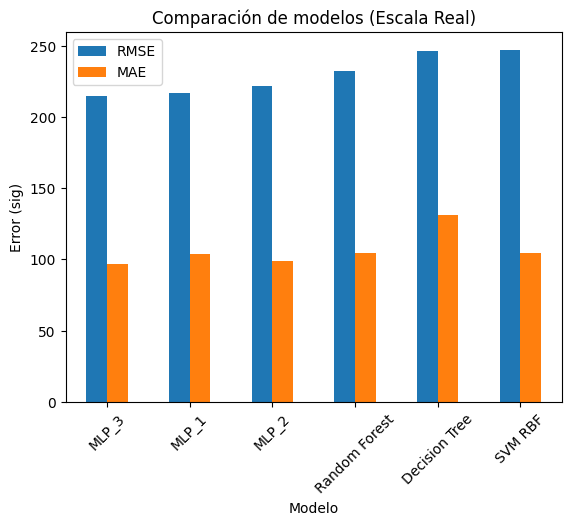

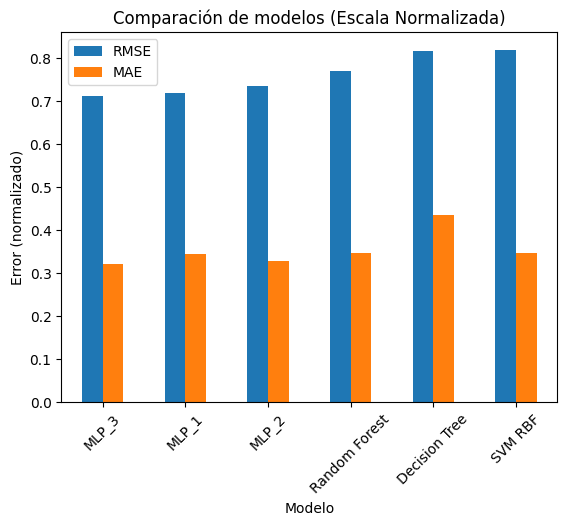

In [ ]:
import matplotlib.pyplot as plt

# =========================
# GRÁFICA ESCALA REAL
# =========================

df_real.set_index("Modelo")[["RMSE", "MAE"]].plot(kind="bar")

plt.title("Comparación de modelos (Escala Real)")
plt.ylabel("Error (sig)")
plt.xlabel("Modelo")
plt.xticks(rotation=45)
plt.show()


# =========================
# GRÁFICA ESCALA NORMALIZADA
# =========================

df_norm.set_index("Modelo")[["RMSE", "MAE"]].plot(kind="bar")

plt.title("Comparación de modelos (Escala Normalizada)")
plt.ylabel("Error (normalizado)")
plt.xlabel("Modelo")
plt.xticks(rotation=45)
plt.show()

# **ENTREGA 3**

En esta tercera entrega se aplica análisis no supervisado al conjunto de datos, realizando primero el escalado de las variables numéricas y luego una reducción de dimensionalidad a dos componentes para facilitar la visualización. Posteriormente, se utilizan los algoritmos `K-Means` y `DBSCAN` para identificar posibles agrupamientos. La variable `alert`, aunque corresponde a una variable de clasificación, se usa únicamente como referencia para cumplir con los objetivos de la actividad, entendiendo que no necesariamente permitirá obtener agrupamientos significativos.

## **1. Escalado de datos con MinMaxScaler**

Se aplica MinMaxScaler para normalizar todas las variables numéricas en un rango entre 0 y 1. Esto es importante porque algoritmos como KMeans y DBSCAN se basan en distancias, y sin escalado las variables con rangos mayores podrían influir más en el agrupamiento.


In [ ]:
#@title Código
from sklearn.preprocessing import MinMaxScaler
# quitar target
X = df.drop(columns=['alert'])

# seleccionar solo columnas numéricas
X = X.select_dtypes(include=['int64', 'float64'])

print("Shape:", X.shape)

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

print("Shape escalado:", X_scaled.shape)

Shape: (1000, 11)
Shape escalado: (1000, 11)


## **2. Reducción Dimensional con PCA**

Esto permite representar los datos en un espacio bidimensional, facilitando la visualización y conservando la mayor cantidad posible de variabilidad de la información original.

In [ ]:
#@title Código
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Varianza explicada por componente:")
print(pca.explained_variance_ratio_)

print("Varianza acumulada:")
print(np.sum(pca.explained_variance_ratio_))

Varianza explicada por componente:
[0.37774532 0.18927018]
Varianza acumulada:
0.5670155024623866


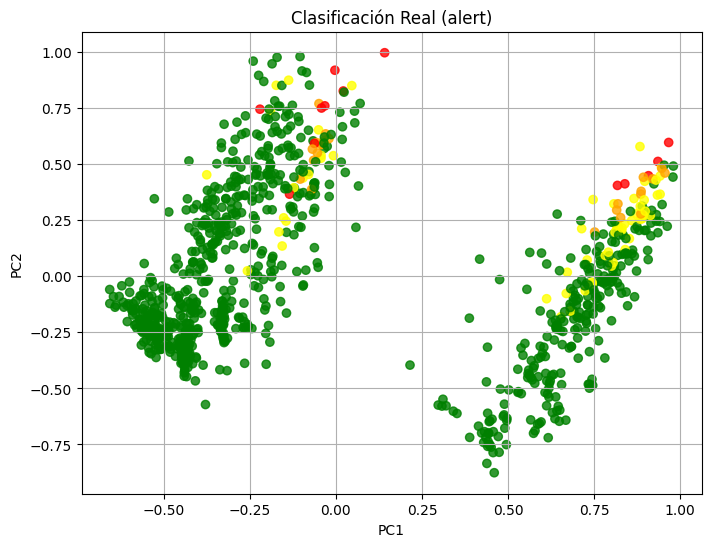

In [ ]:
#@title Datos reales
y_alert = df['alert'].fillna('green')

color_map = {
    'green': 'green',
    'yellow': 'yellow',
    'orange': 'orange',
    'red': 'red'
}

real_colors = y_alert.map(color_map)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=real_colors,
    alpha=0.8
)

plt.title("Clasificación Real (alert)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

## **3. Aplicación de K-Means Clustering**

Se implementa el algoritmo KMeans con n_clusters = 4 para dividir el conjunto de datos en cuatro grupos según su similitud. Este algoritmo busca centroides que minimicen la distancia entre los puntos y el centro de su respectivo cluster.

In [ ]:
#@title Kmeans
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_pca)

centroids = kmeans.cluster_centers_

print("Clusters KMeans:")
print(np.unique(kmeans_labels))

Clusters KMeans:
[0 1 2 3]


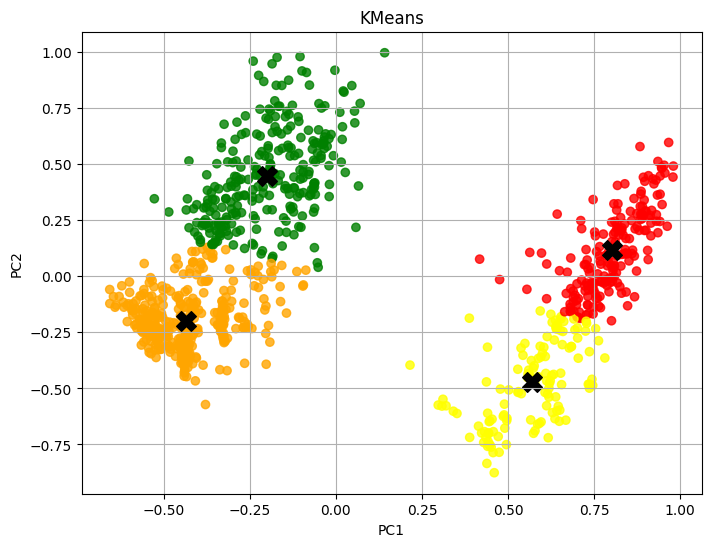

In [ ]:
#@title Gráfica
kmeans_color_map = {
    0: 'green',
    1: 'yellow',
    2: 'orange',
    3: 'red'
}

kmeans_colors = pd.Series(kmeans_labels).map(kmeans_color_map)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=kmeans_colors,
    alpha=0.8
)

plt.scatter(
    centroids[:,0],
    centroids[:,1],
    c='black',
    marker='X',
    s=200
)

plt.title("KMeans")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

## **4. Búsqueda de parámetros para DBSCAN**

Se analiza la distancia entre vecinos cercanos (K-Distance Graph) o se realiza una búsqueda automática para encontrar valores adecuados de eps y min_samples. Estos parámetros determinan la densidad mínima necesaria para formar clusters en DBSCAN.

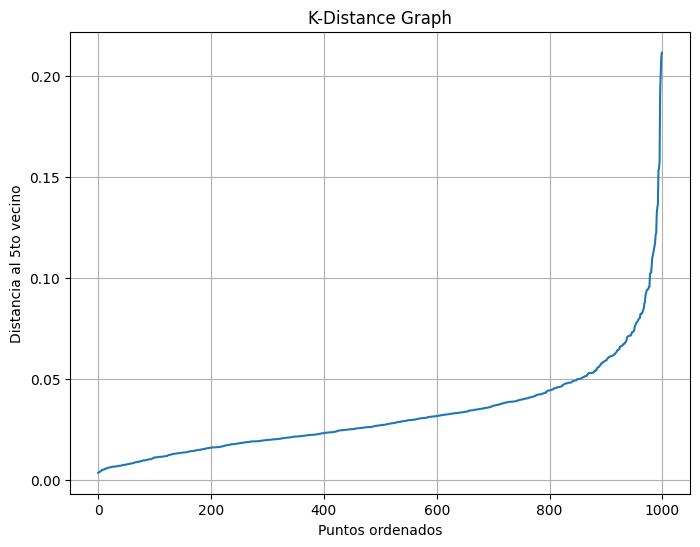

In [ ]:
#@title Codo para DBSCAN
neighbors = NearestNeighbors(n_neighbors=5)

neighbors_fit = neighbors.fit(X_pca)

distances, indices = neighbors_fit.kneighbors(X_pca)

distances = np.sort(distances[:,4])

plt.figure(figsize=(8,6))
plt.plot(distances)

plt.title("K-Distance Graph")
plt.xlabel("Puntos ordenados")
plt.ylabel("Distancia al 5to vecino")
plt.grid(True)
plt.show()

In [ ]:
#@title Mejor eps y minpoints
eps_values = np.arange(0.05, 1.0, 0.05)
min_samples_values = range(3, 10)

best_score = -1
best_eps = None
best_min_samples = None

for eps in eps_values:
    for min_samples in min_samples_values:

        db = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        labels = db.fit_predict(X_pca)

        # quitar ruido
        mask = labels != -1

        # debe haber al menos 2 clusters
        if len(set(labels[mask])) > 1:
            score = silhouette_score(
                X_pca[mask],
                labels[mask]
            )

            if score > best_score:
                best_score = score
                best_eps = eps
                best_min_samples = min_samples

print("Mejor eps:", best_eps)
print("Mejor min_samples:", best_min_samples)
print("Mejor Silhouette:", best_score)

Mejor eps: 0.1
Mejor min_samples: 9
Mejor Silhouette: 0.6165943996968654


In [ ]:
#@title DBSCAN
dbscan = DBSCAN(
    eps=best_eps,
    min_samples=best_min_samples
)

dbscan_labels = dbscan.fit_predict(X_pca)

n_clusters = len(set(dbscan_labels)) - (
    1 if -1 in dbscan_labels else 0
)

noise_points = list(dbscan_labels).count(-1)

print("Clusters encontrados:", n_clusters)
print("Ruido detectado:", noise_points)

Clusters encontrados: 2
Ruido detectado: 13


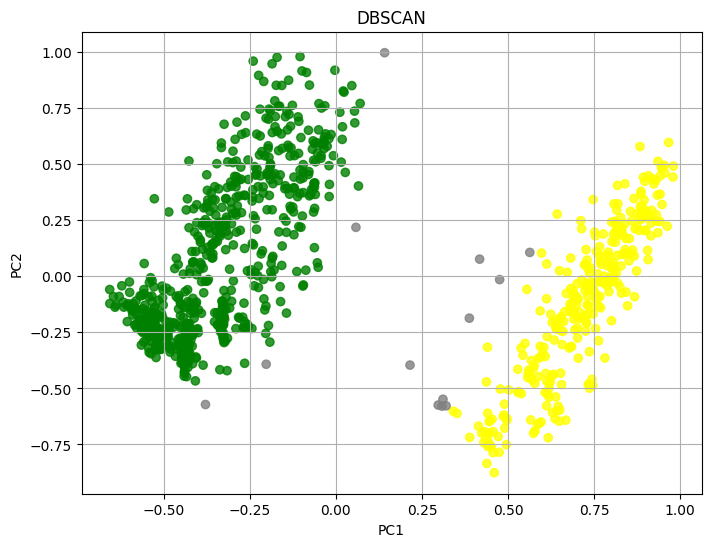

In [ ]:
#@title Gráfica
dbscan_color_map = {
    -1: 'gray',   # ruido
    0: 'green',
    1: 'yellow',
    2: 'orange',
    3: 'red'
}

dbscan_colors = pd.Series(dbscan_labels).map(dbscan_color_map)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=dbscan_colors,
    alpha=0.8
)

plt.title("DBSCAN")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

## **5. Comparacion para la variable alert**
Se compara visualmente o mediante tablas de contingencia cómo se relacionan los clusters encontrados con las clases reales de la variable alert (green, yellow, orange, red). Esto permite evaluar si los patrones naturales del dataset coinciden con las alertas sísmicas.


In [ ]:
#@title Evaluación
kmeans_score = silhouette_score(
    X_pca,
    kmeans_labels
)

print("Silhouette KMeans:", kmeans_score)


# DBSCAN
mask = dbscan_labels != -1

if len(set(dbscan_labels[mask])) > 1:
    dbscan_score = silhouette_score(
        X_pca[mask],
        dbscan_labels[mask]
    )

    print("Silhouette DBSCAN:", dbscan_score)

Silhouette KMeans: 0.6038786547814541
Silhouette DBSCAN: 0.6165943996968654


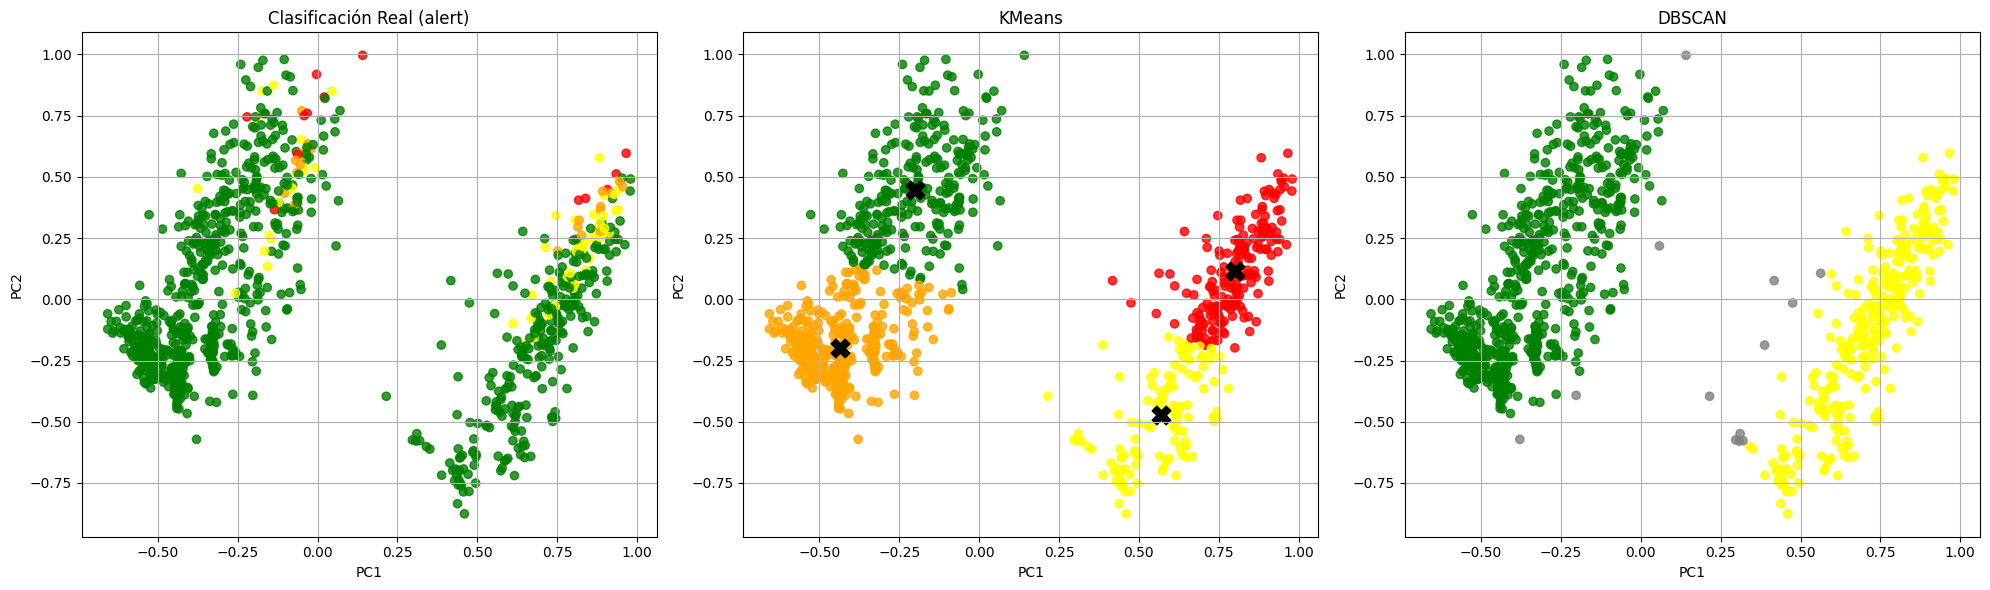

In [ ]:
#@title Gráfica
fig, axes = plt.subplots(
    1, 3,
    figsize=(20,6)
)

# -------- ALERT REAL --------
axes[0].scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=real_colors,
    alpha=0.8
)
axes[0].set_title("Clasificación Real (alert)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].grid(True)

# -------- KMEANS --------
axes[1].scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=kmeans_colors,
    alpha=0.8
)

axes[1].scatter(
    centroids[:,0],
    centroids[:,1],
    c='black',
    marker='X',
    s=180
)

axes[1].set_title("KMeans")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].grid(True)

# -------- DBSCAN --------
axes[2].scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=dbscan_colors,
    alpha=0.8
)

axes[2].set_title("DBSCAN")
axes[2].set_xlabel("PC1")
axes[2].set_ylabel("PC2")
axes[2].grid(True)

plt.tight_layout()
plt.show()